In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import segmentation_models_pytorch as smp
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
# Klasyfikator
classifier = models.efficientnet_b0(weights=None)
classifier.classifier[1] = nn.Linear(classifier.classifier[1].in_features, 2)
classifier.load_state_dict(torch.load('../models/melanoma_model.pth', map_location='cpu'))
classifier.eval()

# U-Net
unet = smp.Unet(
    encoder_name='efficientnet-b0',
    encoder_weights=None,
    in_channels=3,
    classes=1,
)
unet.load_state_dict(torch.load('../models/unet_melanoma.pth', map_location='cpu'))
unet.eval()

print('Oba modele wczytane!')

Oba modele wczytane!


In [4]:
def run_pipeline(image_path):
    # 1. Wczytaj zdjęcie
    img = Image.open(image_path).convert('RGB')
    img_np = np.array(img)
    
    # 2. U-Net → maska
    img_unet = torch.tensor(np.array(img.resize((256, 256)))).permute(2, 0, 1).float() / 255.0
    img_unet = img_unet.unsqueeze(0)
    
    with torch.no_grad():
        mask = torch.sigmoid(unet(img_unet))
        mask = (mask > 0.5).float().squeeze()
    
    mask_np = mask.numpy()
    
    # 3. Klasyfikator na oryginalnym zdjęciu
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_clf = transform(img).unsqueeze(0)
    
    with torch.no_grad():
        outputs = classifier(img_clf)
        probs = torch.softmax(outputs, dim=1)
        predicted = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted].item()
    
    class_names = ['benign', 'malignant']
    
    # 4. Wizualizacja
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img.resize((256, 256)))
    axes[0].set_title('Original')
    axes[1].imshow(mask_np, cmap='gray')
    axes[1].set_title('Mask (U-Net)')
    
    # nałóż maskę na zdjęcie
    overlay = np.array(img.resize((256, 256)))
    overlay[mask_np > 0.5] = [255, 0, 0]  # czerwony kontur
    axes[2].imshow(overlay)
    axes[2].set_title(f'{class_names[predicted]} ({confidence:.2%})')
    plt.tight_layout()
    plt.show()
    
    return class_names[predicted], confidence

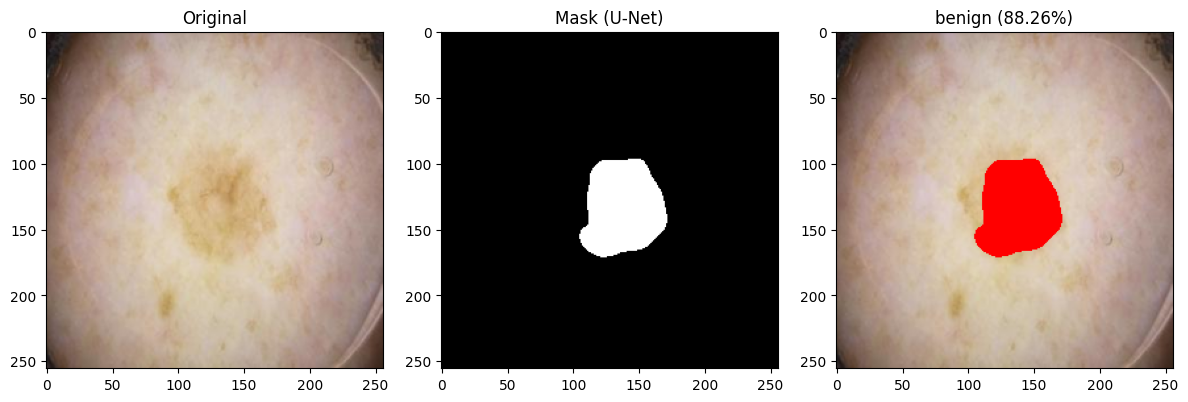

In [13]:
result = run_pipeline('../test_images/melanoma_9927.jpg')

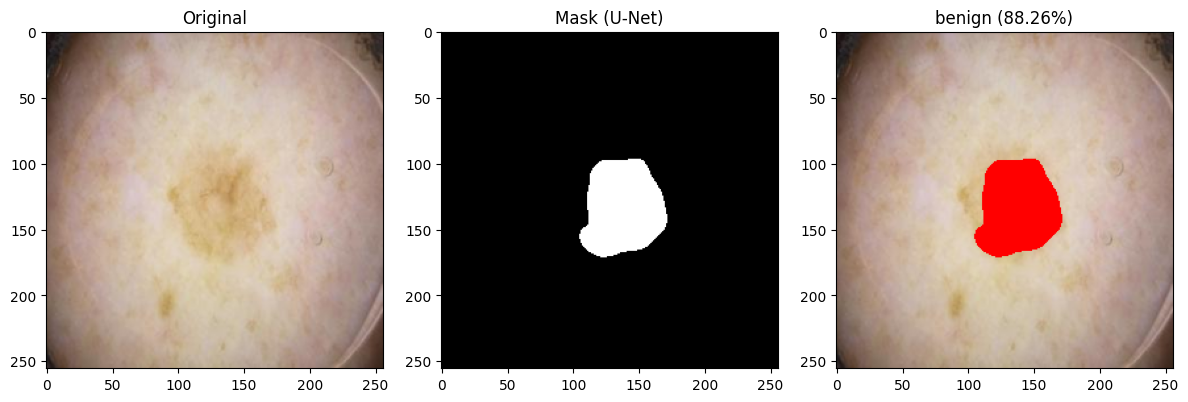

In [ ]:
result = run_pipeline('../test_images/melanoma_9927.jpg')

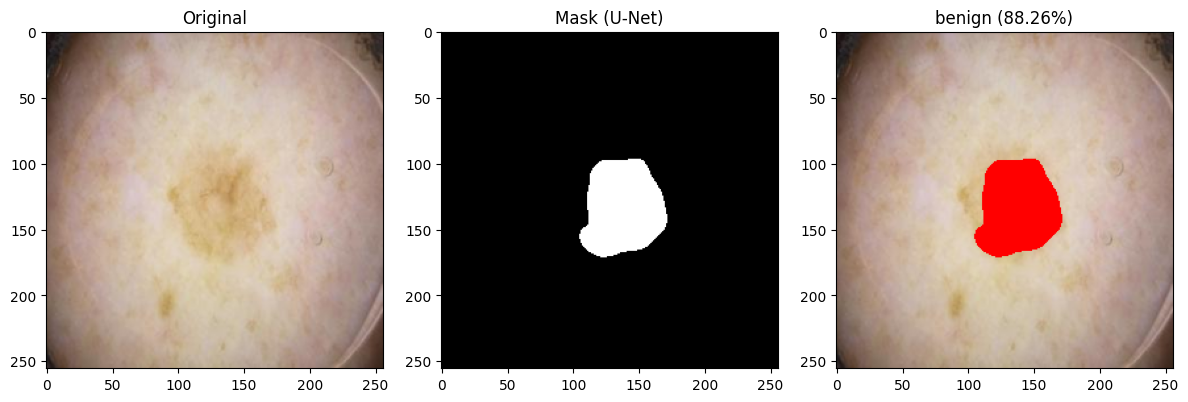

In [ ]:
result = run_pipeline('../test_images/melanoma_9927.jpg')

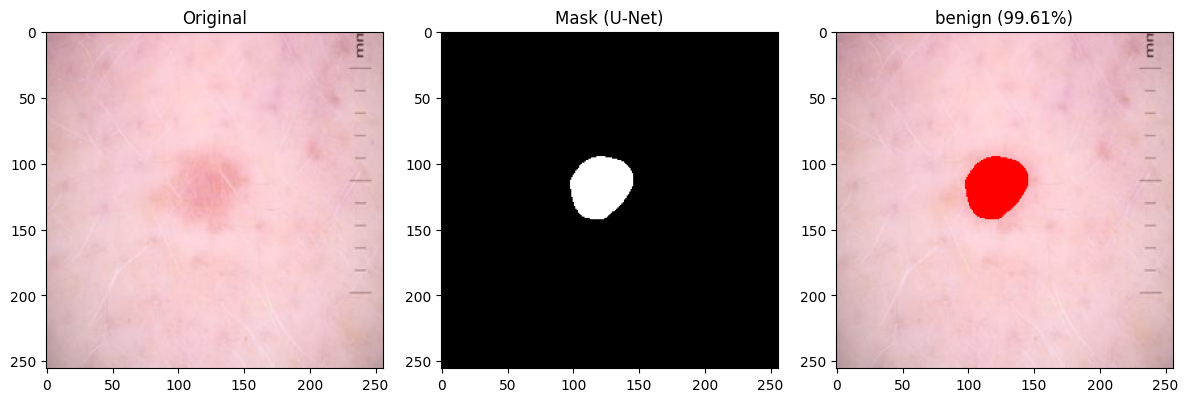

In [14]:
result = run_pipeline('../test_images/melanoma_9990.jpg')

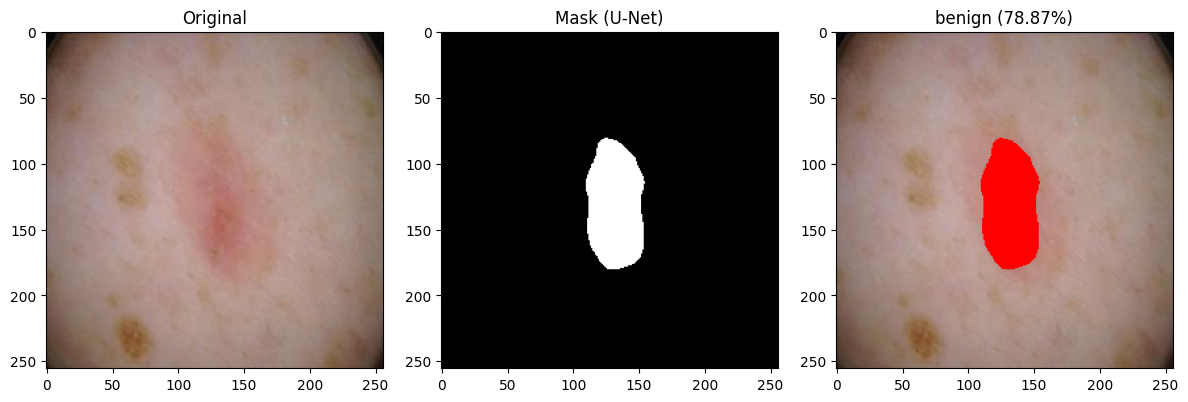

In [15]:
result = run_pipeline('../test_images/melanoma_10592.jpg')

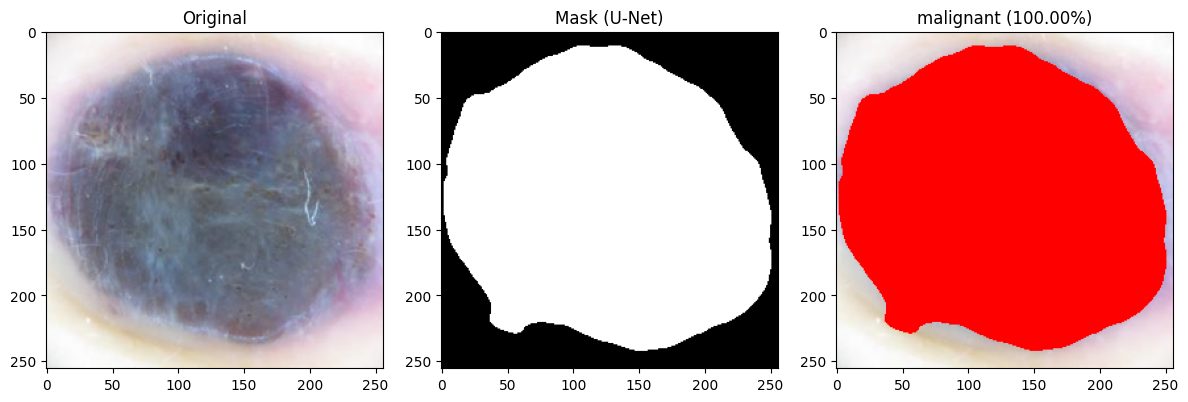

In [16]:
result = run_pipeline('../test_images/melanoma_10530.jpg')

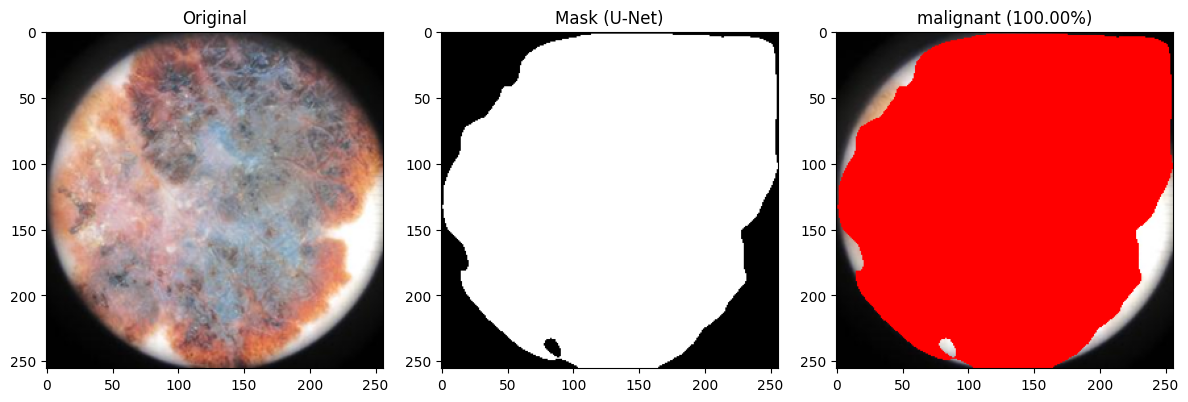

In [19]:
result = run_pipeline('../test_images/melanoma_10502.jpg')

In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img = Image.open('../test_images/melanoma_10502.jpg').convert('RGB')
img_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    outputs = classifier(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    predicted = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted].item()

class_names = ['benign', 'malignant']
print(f'{class_names[predicted]} ({confidence:.2%})')

malignant (100.00%)


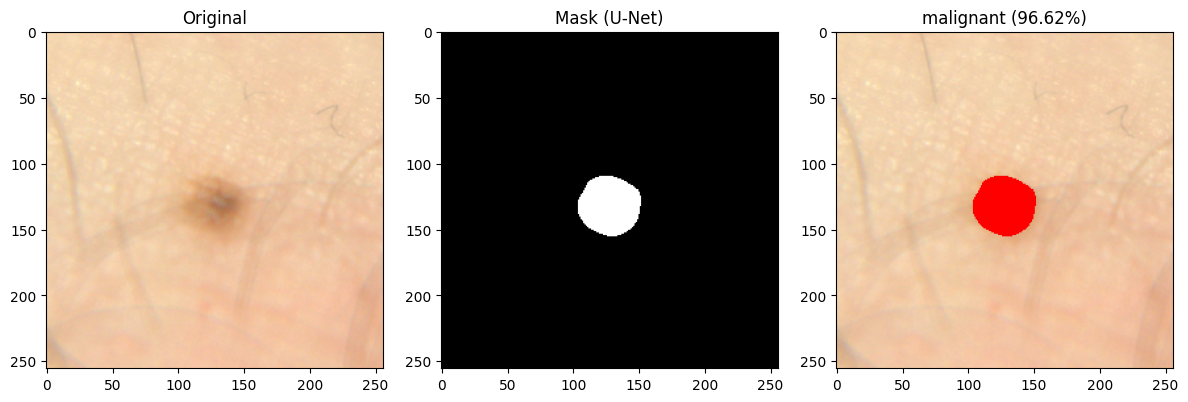

In [4]:
result = run_pipeline('../test_images/DSC02686_cropped.jpg')

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img = Image.open('../test_images/DSC02686_cropped.jpg').convert('RGB')
img_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    outputs = classifier(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    predicted = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted].item()

class_names = ['benign', 'malignant']
print(f'{class_names[predicted]} ({confidence:.2%})')

malignant (96.62%)


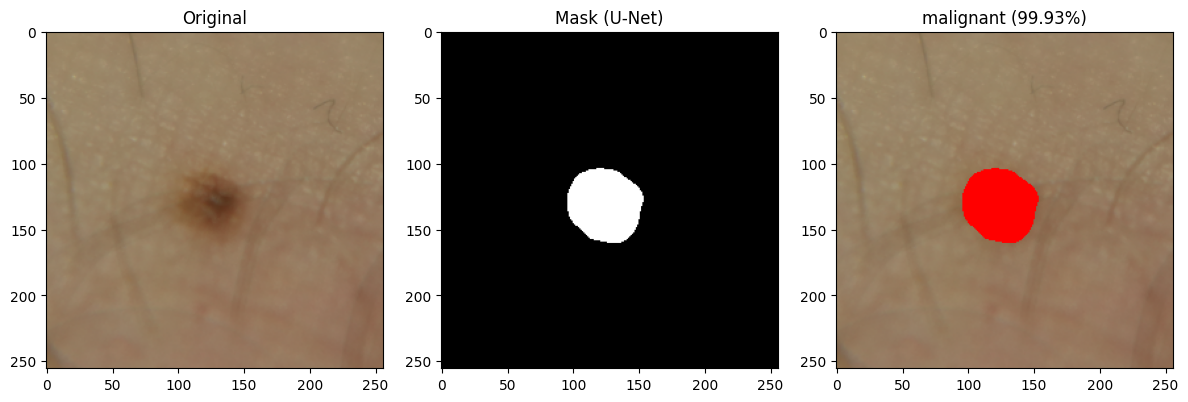

In [8]:
result = run_pipeline('../test_images/DSC026861_cropped.jpg')

In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img = Image.open('../test_images/DSC026861_cropped.jpg').convert('RGB')
img_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    outputs = classifier(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    predicted = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted].item()

class_names = ['benign', 'malignant']
print(f'{class_names[predicted]} ({confidence:.2%})')

malignant (99.93%)
